In [1]:
#Phase 1 = data cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')   # /content/data.csv if you're on Colab

print(df.head)
df.info()

print(df.shape)       # (569, 32)
print(df.columns.tolist())  # see all column names
df.head()             # first 5 rows
print(df.isnull().sum()) #checking for null values
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True) #dropping 2 unwanted coloumns (id since its not a measurement & empty col)

print(df.shape) #total 31 coloumns - 30 features & 1 diagnosis col

<bound method NDFrame.head of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0  

diagnosis
B    357
M    212
Name: count, dtype: int64


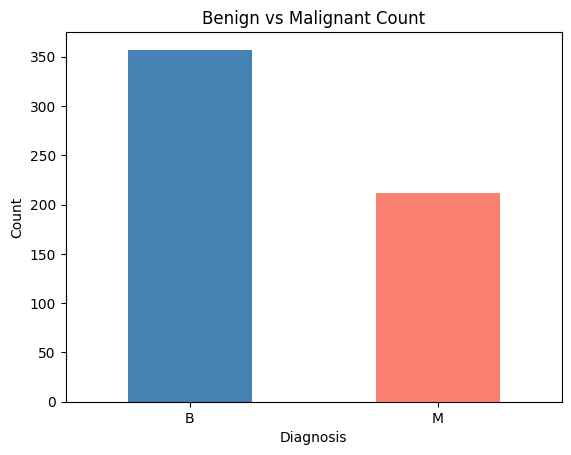

In [2]:
#Phase 2 - data visualisation
#1. class balance check

print(df['diagnosis'].value_counts())
# B    357
# M    212

df['diagnosis'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Benign vs Malignant Count')
plt.xticks(rotation=0)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

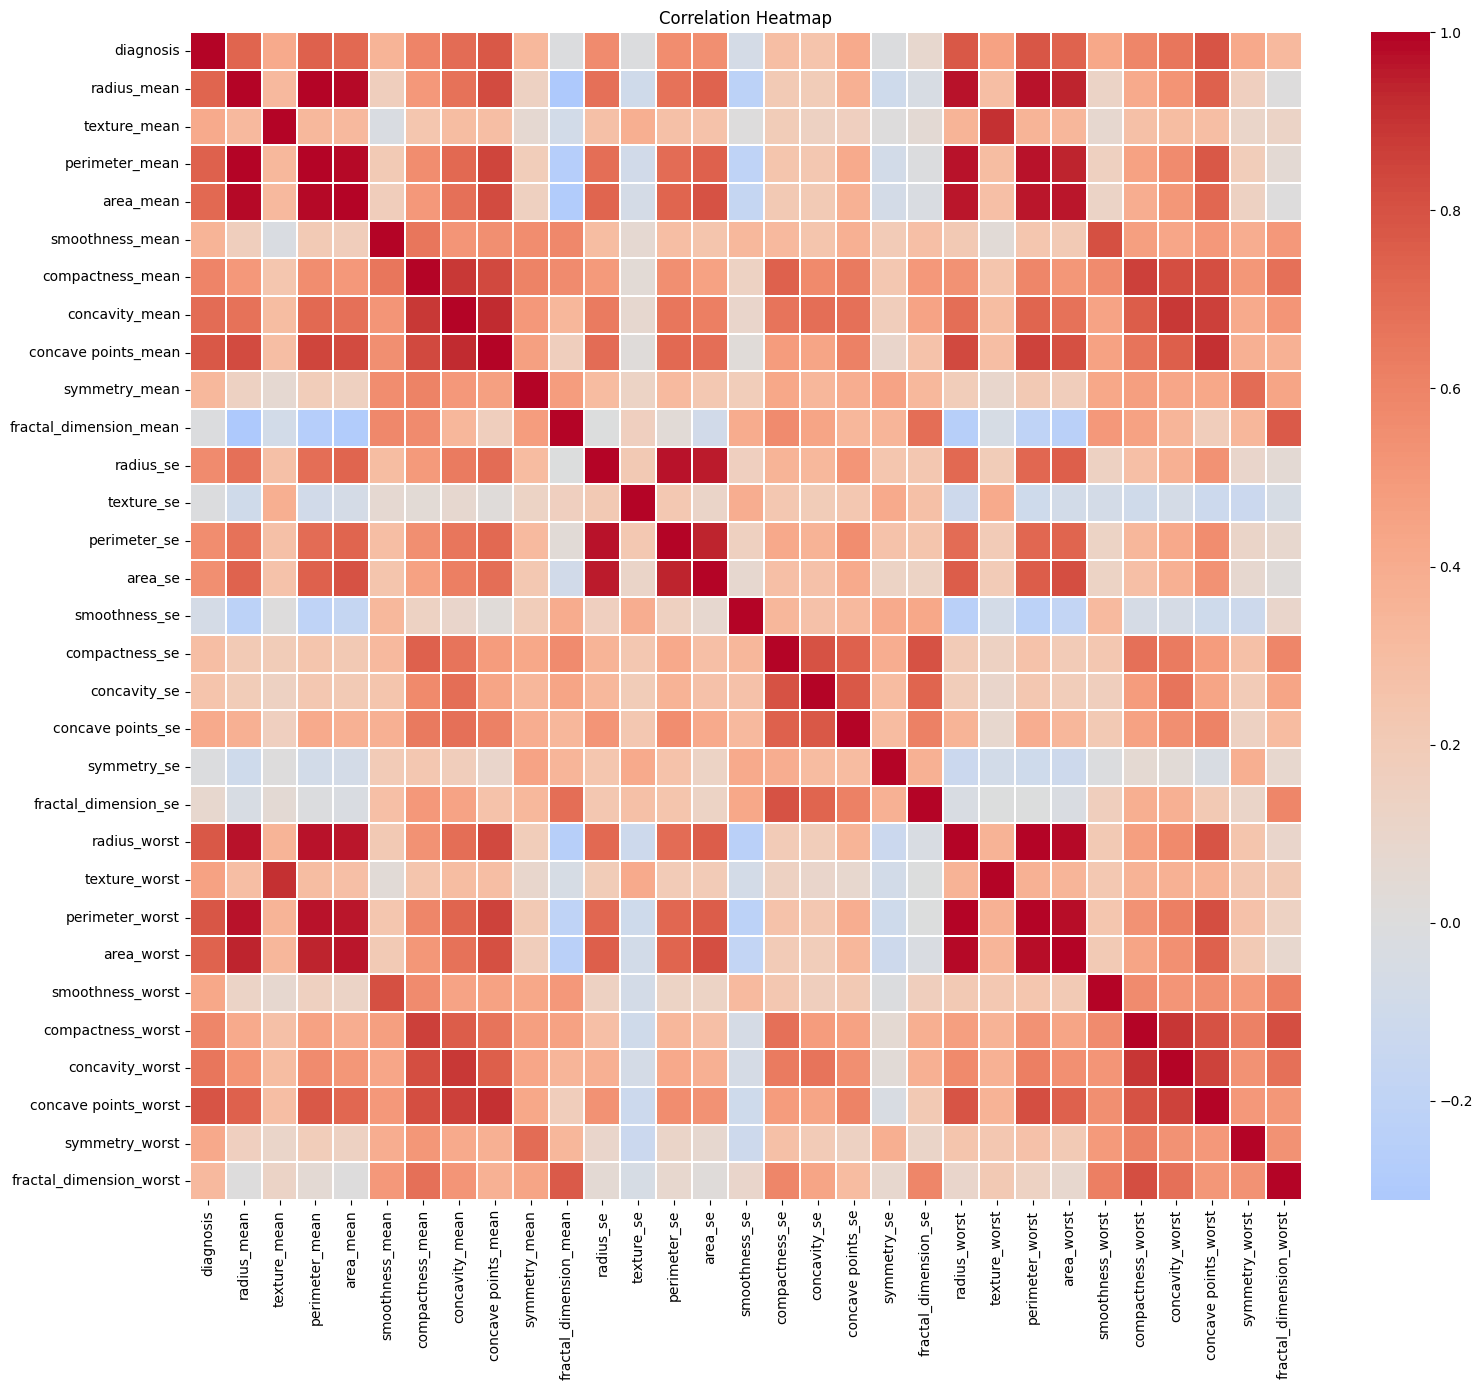

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


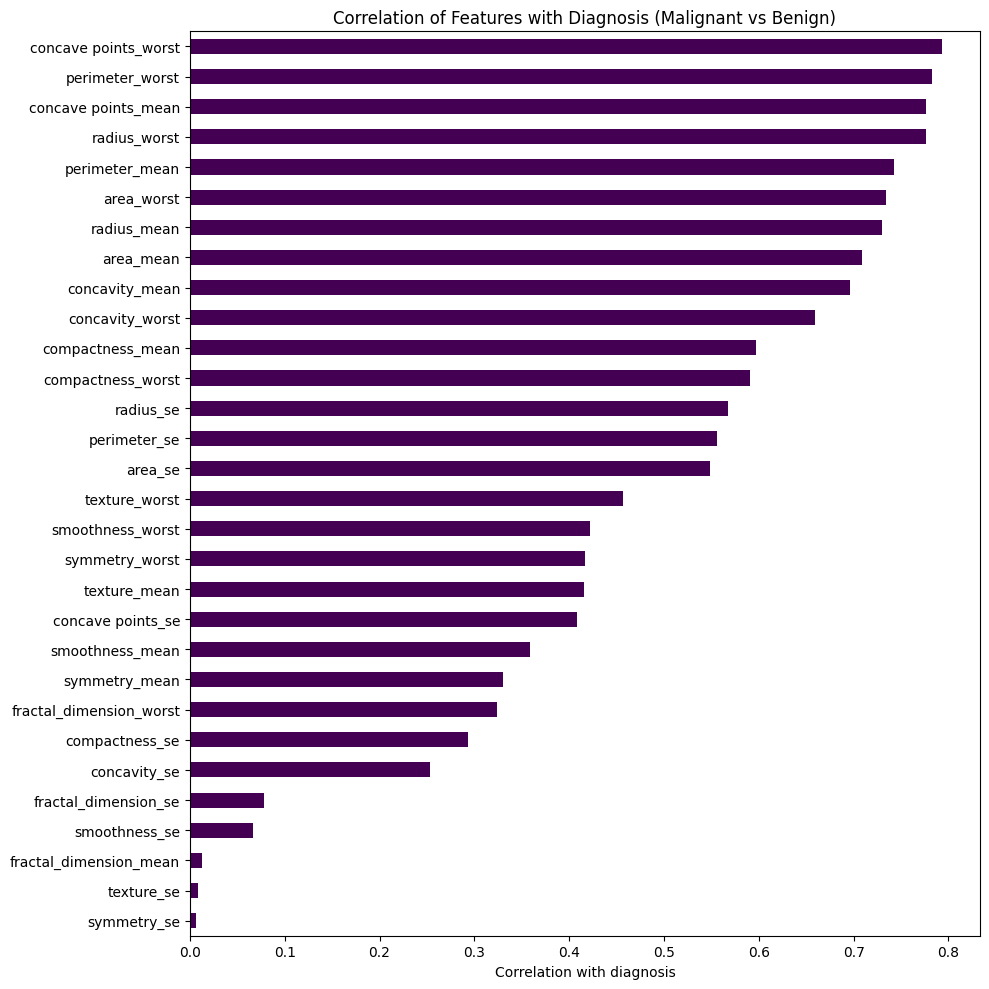

In [3]:
# 2. Correlation Heatmap
df_temp = df.copy()
df_temp['diagnosis'] = df_temp['diagnosis'].map({'M': 1, 'B': 0}) #converting diagnosis value in binary (M=1/B=0)

plt.figure(figsize=(16, 14))
sns.heatmap(df_temp.corr(), cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr = df_temp.corr()['diagnosis'].sort_values(ascending=False) #more accurate since value is closer to 1.
print(corr.head(11))

# Plot it as a horizontal bar chart 
corr_no_diag = corr.drop('diagnosis')  # remove the self-correlation

plt.figure(figsize=(10, 10))
corr_no_diag.abs().sort_values().plot(kind='barh', colormap='viridis')
plt.title('Correlation of Features with Diagnosis (Malignant vs Benign)')
plt.xlabel('Correlation with diagnosis')
plt.tight_layout()
plt.show()


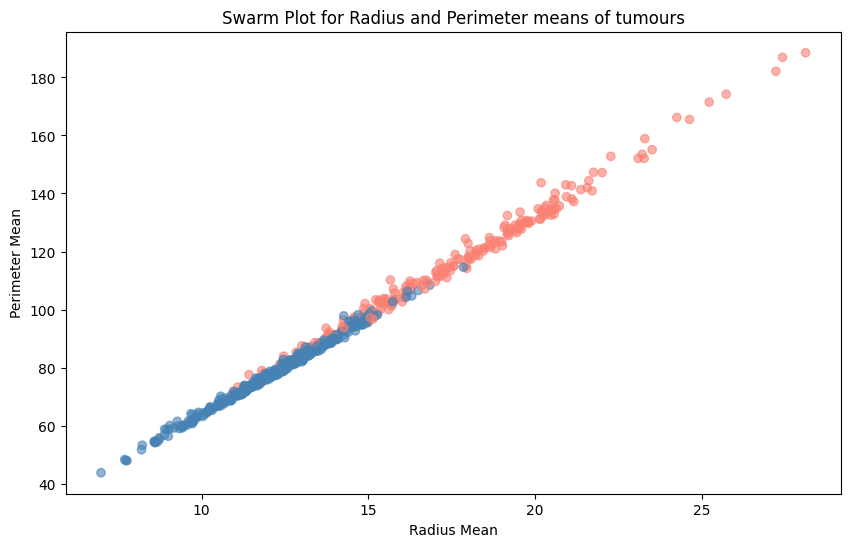

In [4]:
#notes: from this its clear of our most predicitve features (top 4 features = values closer to 1 the better = stronger positive relationship to malignancy.)

#4. Scatter/Swarm Plot to visualise rs bw perimeter & radius + spot outliers (rare cases that stand out esp in medical data)
plt.figure(figsize=(10, 6))
plt.scatter(df['radius_mean'], df['perimeter_mean'],
c=df['diagnosis'].map({'M': 'salmon', 'B': 'steelblue'}),
alpha=0.6)
plt.title('Swarm Plot for Radius and Perimeter means of tumours')
plt.xlabel('Radius Mean')
plt.ylabel('Perimeter Mean')
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_92068\2896550535.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y='radius_mean', palette=['steelblue', 'salmon'])


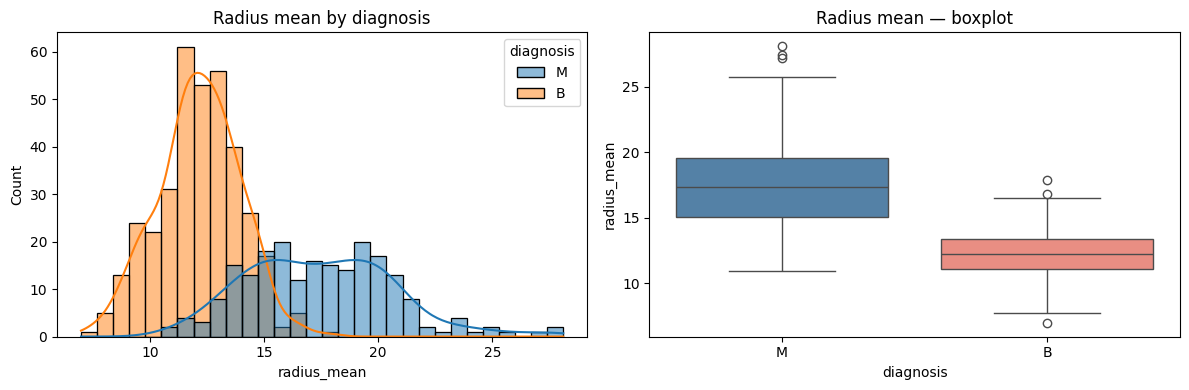

In [5]:
# How does radius_mean differ between classes?
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, bins=30)
plt.title('Radius mean by diagnosis')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='diagnosis', y='radius_mean', palette=['steelblue', 'salmon'])
plt.title('Radius mean — boxplot')
plt.tight_layout()
plt.show()

In [6]:
#Phase 3 = Data Preprocessing (includes encoding, normalisation, scaling)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}) #encoding
print(df['diagnosis'].value_counts())

X = df.drop('diagnosis', axis=1)  
y = df['diagnosis']               

print(f"X shape: {X.shape}") 
print(f"y shape: {y.shape}") 


diagnosis
0    357
1    212
Name: count, dtype: int64
X shape: (569, 30)
y shape: (569,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% → 114 samples for testing
    random_state=42,   # same split every run, for every team member
    stratify=y         # keeps 63/37 ratio in both train and test
)

print(f"X_train: {X_train.shape}")  # (455, 30)
print(f"X_test:  {X_test.shape}")   # (114, 30)
print(f"\nTraining labels:\n{y_train.value_counts()}")
# 0    285
# 1    170
print(f"\nTesting labels:\n{y_test.value_counts()}")
# 0    72
# 1    42

X_train: (455, 30)
X_test:  (114, 30)

Training labels:
diagnosis
0    285
1    170
Name: count, dtype: int64

Testing labels:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [8]:
#Standard Scalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(X_train_sc[0])  # first row — mix of positive and negative numbers

#Robust Scaler 
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
X_train_robust = robust.fit_transform(X_train)
X_test_robust  = robust.transform(X_test)

print(f"X_train_robust shape: {X_train_robust.shape}")  # (455, 30)
print(f"X_test_robust shape:  {X_test_robust.shape}")   # (114, 30)

[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371 -0.6897715
 -0.68858645 -0.39817525 -1.0391547  -0.82505632 -0.10931776 -0.05597554
 -0.21009621 -0.01591326 -1.00518399 -0.91194199 -0.66281588 -0.65256108
 -0.70188911 -0.27539357  0.5797977   1.31324246  0.46690813  0.44598271
 -0.59615478 -0.63472223 -0.6102273  -0.23574392  0.05456632  0.02183673]
X_train_robust shape: (455, 30)
X_test_robust shape:  (114, 30)


Training accuracy: 0.9824
Test accuracy: 0.9123
              precision    recall  f1-score   support

      Benign       0.90      0.97      0.93        72
   Malignant       0.94      0.81      0.87        42

    accuracy                           0.91       114
   macro avg       0.92      0.89      0.90       114
weighted avg       0.91      0.91      0.91       114

AUC-ROC: 0.9673


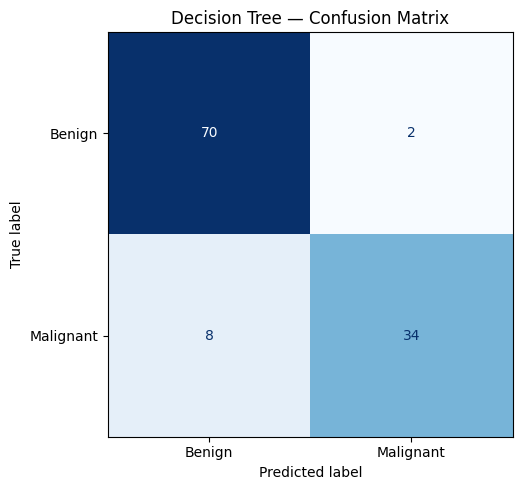

In [9]:
#Training Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier( criterion='gini', max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42 )
dt.fit(X_train_sc, y_train) 
y_pred = dt.predict(X_test_sc)
print(f"Training accuracy: {dt.score(X_train_sc, y_train):.4f}")
print(f"Test accuracy: {dt.score(X_test_sc, y_test):.4f}")

from sklearn.metrics import ( classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
print(classification_report( y_test, y_pred, target_names=['Benign', 'Malignant'] ))
y_proba = dt.predict_proba(X_test_sc)[:, 1] 
auc = roc_auc_score(y_test, y_proba) 
print(f"AUC-ROC: {auc:.4f}")


#Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5)) 
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=['Benign', 'Malignant'] ).plot(ax=ax, cmap='Blues', colorbar=False) 
plt.title('Decision Tree — Confusion Matrix') 
plt.tight_layout() 
plt.show()



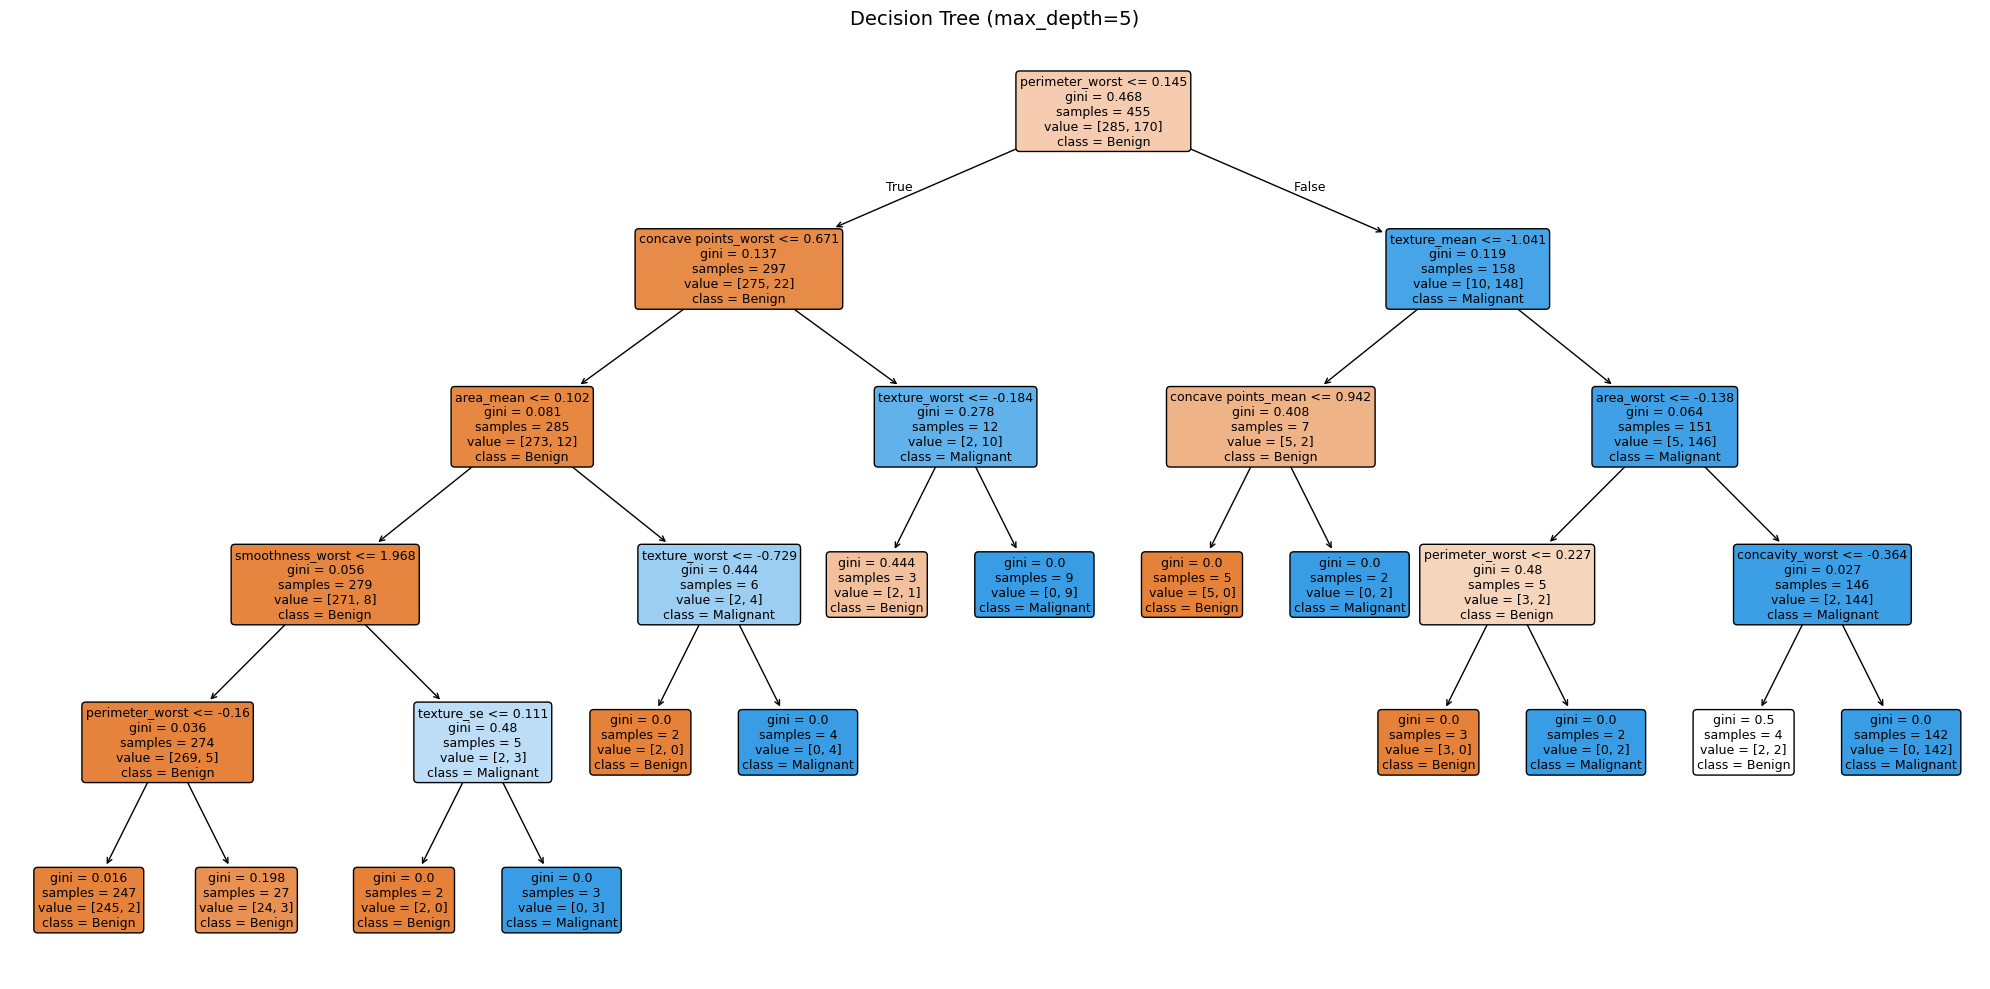

|--- perimeter_worst <= 0.14
|   |--- concave points_worst <= 0.67
|   |   |--- area_mean <= 0.10
|   |   |   |--- smoothness_worst <= 1.97
|   |   |   |   |--- perimeter_worst <= -0.16
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- perimeter_worst >  -0.16
|   |   |   |   |   |--- class: 0
|   |   |   |--- smoothness_worst >  1.97
|   |   |   |   |--- texture_se <= 0.11
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- texture_se >  0.11
|   |   |   |   |   |--- class: 1
|   |   |--- area_mean >  0.10
|   |   |   |--- texture_worst <= -0.73
|   |   |   |   |--- class: 0
|   |   |   |--- texture_worst >  -0.73
|   |   |   |   |--- class: 1
|   |--- concave points_worst >  0.67
|   |   |--- texture_worst <= -0.18
|   |   |   |--- class: 0
|   |   |--- texture_worst >  -0.18
|   |   |   |--- class: 1
|--- perimeter_worst >  0.14
|   |--- texture_mean <= -1.04
|   |   |--- concave points_mean <= 0.94
|   |   |   |--- class: 0
|   |   |--- concave points_mean >  0.94
|   |   |

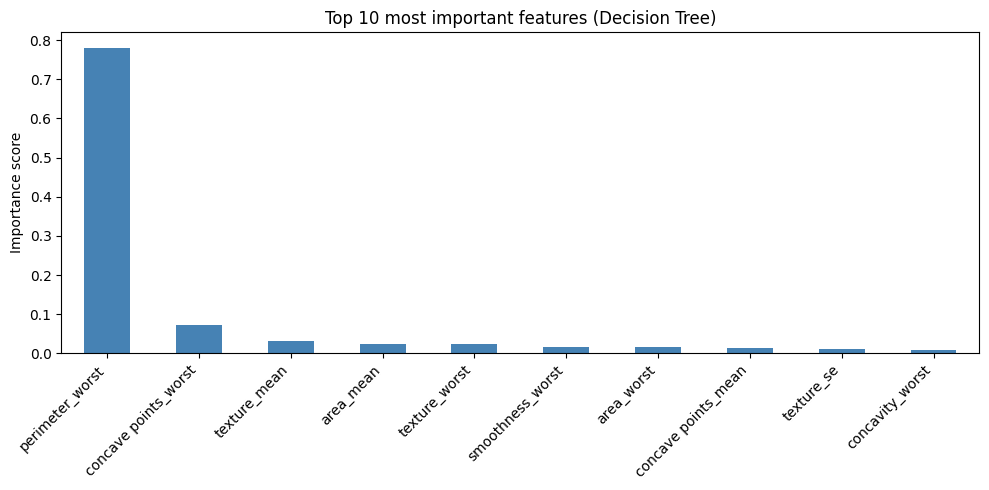

perimeter_worst         0.780744
concave points_worst    0.071970
texture_mean            0.030989
area_mean               0.023868
texture_worst           0.023295
smoothness_worst        0.016591
area_worst              0.016591
concave points_mean     0.014262
texture_se              0.011980
concavity_worst         0.009710
dtype: float64


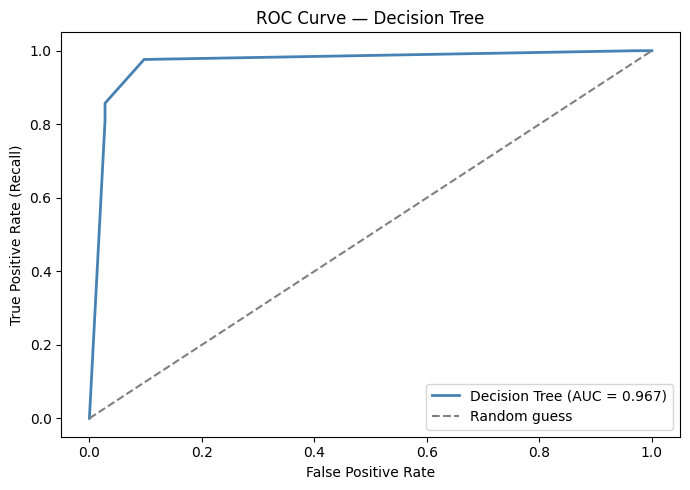

Model and scaler saved successfully!


In [12]:
#Visualising the Tree
from sklearn.tree import plot_tree 
plt.figure(figsize=(20, 10)) 
plot_tree(dt, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True, rounded=True, fontsize=9, impurity=True, proportion=False )
plt.title('Decision Tree (max_depth=5)', fontsize=14) 
plt.tight_layout()
plt.show()
from sklearn.tree import export_text 
print(export_text(dt, feature_names=list(X.columns)))

#Feature importance - which feature did the tree rely on the most
importances = pd.Series( dt.feature_importances_, index=X.columns ).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='none') 
plt.title('Top 10 most important features (Decision Tree)')
plt.ylabel('Importance score') 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show() 
print(importances.head(10))

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba) 
plt.figure(figsize=(7, 5)) 
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Decision Tree (AUC = {auc:.3f})') 
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)') 
plt.title('ROC Curve — Decision Tree') 
plt.legend() 
plt.tight_layout() 
plt.show()

import pickle

# Save your trained model
with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(dt, f)

# Save your scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")



In [15]:
#Interface 

import numpy as np
import pandas as pd
import pickle
import datetime
import os

MODEL_FILE  = "decision_tree_model.pkl"
SCALER_FILE = "scaler.pkl"
DATA_FILE   = "data.csv"

def load_assets():
    missing = [f for f in [MODEL_FILE, SCALER_FILE, DATA_FILE] if not os.path.exists(f)]
    if missing:
        print(f"\nError: Missing files: {', '.join(missing)}")
        print("Place them in the same folder as this script.\n")
        exit(1)
 

 
    with open(MODEL_FILE,  "rb") as f: model  = pickle.load(f)
    with open(SCALER_FILE, "rb") as f: scaler = pickle.load(f)
 
    df = pd.read_csv(DATA_FILE)
    df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
    df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
    feature_names = list(df.drop(columns=["diagnosis"]).columns)
 
    return model, scaler, feature_names, df
 
 
def enter_features(feature_names):
    print("\nEnter values for all features.")
    print("(Press Enter to use 0.0 as default)\n")
 
    inputs = []
    for feat in feature_names:
        while True:
            raw = input(f"  {feat}: ").strip()
            if raw == "":
                inputs.append(0.0)
                break
            try:
                inputs.append(float(raw))
                break
            except ValueError:
                print("    Please enter a number.")
 
    return np.array(inputs)
 
 
def show_result(name, age, feature_names, inputs, model, scaler):
    data_df     = pd.DataFrame([inputs], columns=feature_names)
    data_scaled = scaler.transform(data_df)
    prediction  = model.predict(data_scaled)[0]
    proba       = model.predict_proba(data_scaled)[0]
    is_malignant= prediction == 1
    confidence  = proba[1] if is_malignant else proba[0]
    date_str    = datetime.datetime.now().strftime("%d %b %Y  %H:%M")
    model_name  = MODEL_FILE.replace(".pkl", "").replace("_", " ").title()
 
    print("\n" + "=" * 52)
    print("              PREDICTION RESULT")
    print("=" * 52)
    print(f"  Name      : {name}")
    print(f"  Age       : {age}")
    print(f"  Date      : {date_str}")
    print(f"  Model     : {model_name}")
    print("-" * 52)
 
    # Result
    if is_malignant:
        print("\n  Result    : ⚠️ MALIGNANT (Cancer Detected)")
    else:
        print("\n  Result    : ✅ BENIGN (No Cancer Detected)")

# Confidence bar
    bar_len = 30
    filled  = int(confidence * bar_len)
    bar     = "#" * filled + "-" * (bar_len - filled)
    print(f"\n  Confidence: {confidence * 100:.2f}%")
    print(f"  [{bar}]")
 
    # Probability breakdown
    print(f"\n  Probability Breakdown:")
    print(f"    Benign    : {proba[0] * 100:.2f}%")
    print(f"    Malignant : {proba[1] * 100:.2f}%")
 
    # Top 3 contributing features
    scaled_vals = data_scaled[0]
    top3_idx    = np.argsort(np.abs(scaled_vals))[::-1][:3]
    print(f"\n  Top 3 Contributing Measurements:")
    for i, idx in enumerate(top3_idx, 1):
        fname = feature_names[idx]
        print(f"    {i}. {fname:35s} = {inputs[idx]:.4f}")
 
    print("\n" + "-" * 52)
    print("  Note: This is an educational tool only.")
    print("  Always consult a qualified medical professional.")
    print("=" * 52 + "\n")
 
 
def main():
    print("\n" + "=" * 52)
    print("     BREAST CANCER DIAGNOSIS PREDICTOR")
    print("     (Based on the Wisconsin Diagnostic Dataset) ")
    print("=" * 52)
 
    model, scaler, feature_names, df = load_assets()
 
    while True:
        print("\n-- Patient Details --")
        name = input("  Name : ").strip() or "Unknown"
        age  = input("  Age  : ").strip() or "N/A"
 
        print("\nEnter values for all features:\n")
        inputs = enter_features(feature_names)
 
        show_result(name, age, feature_names, inputs, model, scaler)
 
        again = input("Run another prediction? (y / n): ").strip().lower()
        if again not in ("y", "yes"):
            print(f"\nGoodbye, {name}!\n")
            break
 
 
if __name__ == "__main__":
    main()







     BREAST CANCER DIAGNOSIS PREDICTOR
     (Based on the Wisconsin Diagnostic Dataset) 

-- Patient Details --



Enter values for all features:


Enter values for all features.
(Press Enter to use 0.0 as default)


              PREDICTION RESULT
  Name      : Alice
  Age       : 25
  Date      : 06 May 2026  17:13
  Model     : Decision Tree Model
----------------------------------------------------

  Result    : ✅ BENIGN (No Cancer Detected)

  Confidence: 66.67%
  [####################----------]

  Probability Breakdown:
    Benign    : 66.67%
    Malignant : 33.33%

  Top 3 Contributing Measurements:
    1. concave points_worst                = 0.7639
    2. compactness_se                      = 0.1948
    3. concave points_se                   = 0.0675

----------------------------------------------------
  Note: This is an educational tool only.
  Always consult a qualified medical professional.


Goodbye, Alice!

